# Task multi-label training

Trains a single multi-label model on the 4-class task dataset (3 target
species + `non_target`). Outputs are independent sigmoids: a clip can
fire more than one class at a time, which matches reality (multiple birds
can be present in the same window).

Only the float `.keras` model is saved here. PTQ and evaluation live in
`results.ipynb` so PTQ knobs can be re-explored without retraining.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os

import pyrootutils

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [3]:
# COLLECTION is the on-disk dataset folder name produced by
# dataset_build.ipynb, i.e. task_slug(TARGET_SPECIES, LAT, LON, RADIUS_KM).
COLLECTION = "task_s3_49_2_r50"
BUILD_MODEL = "mel_cnn"  # one of: mel_cnn, mel_cnn_2, cnn1d, sincnet, leaf, transformer, squeezenet_mel, squeezenet_time
EPOCHS = 100
PATIENCE = 10
BATCH_SIZE = 32
SEED = 42
NON_TARGET_NAME = "non_target"

# LR schedule: halve LR after `LR_PATIENCE` epochs without val_loss improvement,
# floor at LR_MIN. Sits inside EarlyStopping(patience=PATIENCE) so the model
# gets ~2 LR reductions before training is allowed to stop.
LR_PATIENCE = 3
LR_FACTOR = 0.5
LR_MIN = 1e-5

MODEL_PATH = ROOT / "models" / COLLECTION / f"{BUILD_MODEL}.keras"

## Load dataset catalog + build train/val pipelines

Loads the per-class cached waveform catalog built by `scaling.py` (first run
populates `.cache/<collection>/waveform_<hash>/`; later runs hit the cache),
then constructs the train/val pipelines.

The train pipeline visits every sample exactly once per epoch under the
natural class distribution; class re-weighting happens through the per-sample
inverse-frequency `sample_weight` shown in the `weight` column below.
Validation also uses the natural distribution. The test split is built later
in `results.ipynb` (alongside PTQ).

In [4]:
import logging
import warnings

import numpy as np
import tensorflow as tf

tf.get_logger().setLevel("ERROR")
logging.getLogger("absl").setLevel("ERROR")
warnings.filterwarnings("ignore", message=".*AudioResample.*")

from building.scaling import (
    build_dataset_from_catalog,
    load_dataset_catalog,
    model_factory,
)
from building.models import input_repr_for

catalog = load_dataset_catalog(COLLECTION)

non_target_idx = catalog.class_names.index(NON_TARGET_NAME)
target_idxs = [i for i, n in enumerate(catalog.class_names) if n != NON_TARGET_NAME]
final_labels = [catalog.class_names[i] for i in target_idxs] + [NON_TARGET_NAME]

input_repr = input_repr_for(BUILD_MODEL)
rng = np.random.default_rng(SEED)

train_ds, meta = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="train", input_repr=input_repr, augment=True,
)
val_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="val", input_repr=input_repr, augment=False,
)
print(f"target_idxs={target_idxs}  non_target_idx={non_target_idx}")
print(f"final label order: {final_labels}")
print(f"n_classes={meta.n_classes}  epoch_samples={meta.epoch_samples}")

target_idxs=[0, 1, 2]  non_target_idx=3
final label order: ['Emberiza_calandra', 'Hippolais_polyglotta', 'Regulus_ignicapilla', 'non_target']
n_classes=4  epoch_samples=43752


In [5]:
import pandas as pd

weights_by_name = {final_labels[lbl]: w for lbl, w in meta.class_weights.items()}

rows = [
    (
        e.name,
        e.train.count,
        e.val.count,
        e.test.count,
        e.train.count + e.val.count + e.test.count,
        weights_by_name.get(e.name),
    )
    for e in catalog.entries
]
counts = pd.DataFrame(
    rows, columns=["class", "train", "val", "test", "total", "weight"]
).set_index("class")
counts.loc["TOTAL"] = [
    counts["train"].sum(),
    counts["val"].sum(),
    counts["test"].sum(),
    counts["total"].sum(),
    None,
]

(
    counts.style
    .background_gradient(cmap="Blues", subset=(counts.index[:-1], ["train", "val", "test"]))
    .format(
        {"train": "{:,.0f}", "val": "{:,.0f}", "test": "{:,.0f}",
         "total": "{:,.0f}", "weight": "{:.3f}"},
        na_rep="—",
    )
    .set_caption(f"Sample counts + per-class loss weights  ({COLLECTION})")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "110%"), ("padding", "6px 0")]},
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])
)

,train,val,test,total,weight
class,,,,,
Emberiza_calandra,"7,398","1,567","1,609","10,574",1.189
Hippolais_polyglotta,"6,991","1,506","1,503","10,000",1.258
Regulus_ignicapilla,"7,658","1,638","1,639","10,935",1.148
non_target,"21,705","4,653","4,646","31,004",0.405
TOTAL,"43,752","9,364","9,397","62,513",—


## Build model and train

In [6]:
tf.keras.backend.clear_session()
model = model_factory(BUILD_MODEL)(meta.n_classes)
model.summary()

Model: "cnn2d_mel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_spectrogram (InputLayer)    │ (None, 184, 80, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 182, 78, 4)     │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 91, 39, 4)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 89, 37, 4)      │           148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 44, 18, 4)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3168)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3168)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        25,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,576 (99.91 KB)

 Trainable params: 25,576 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

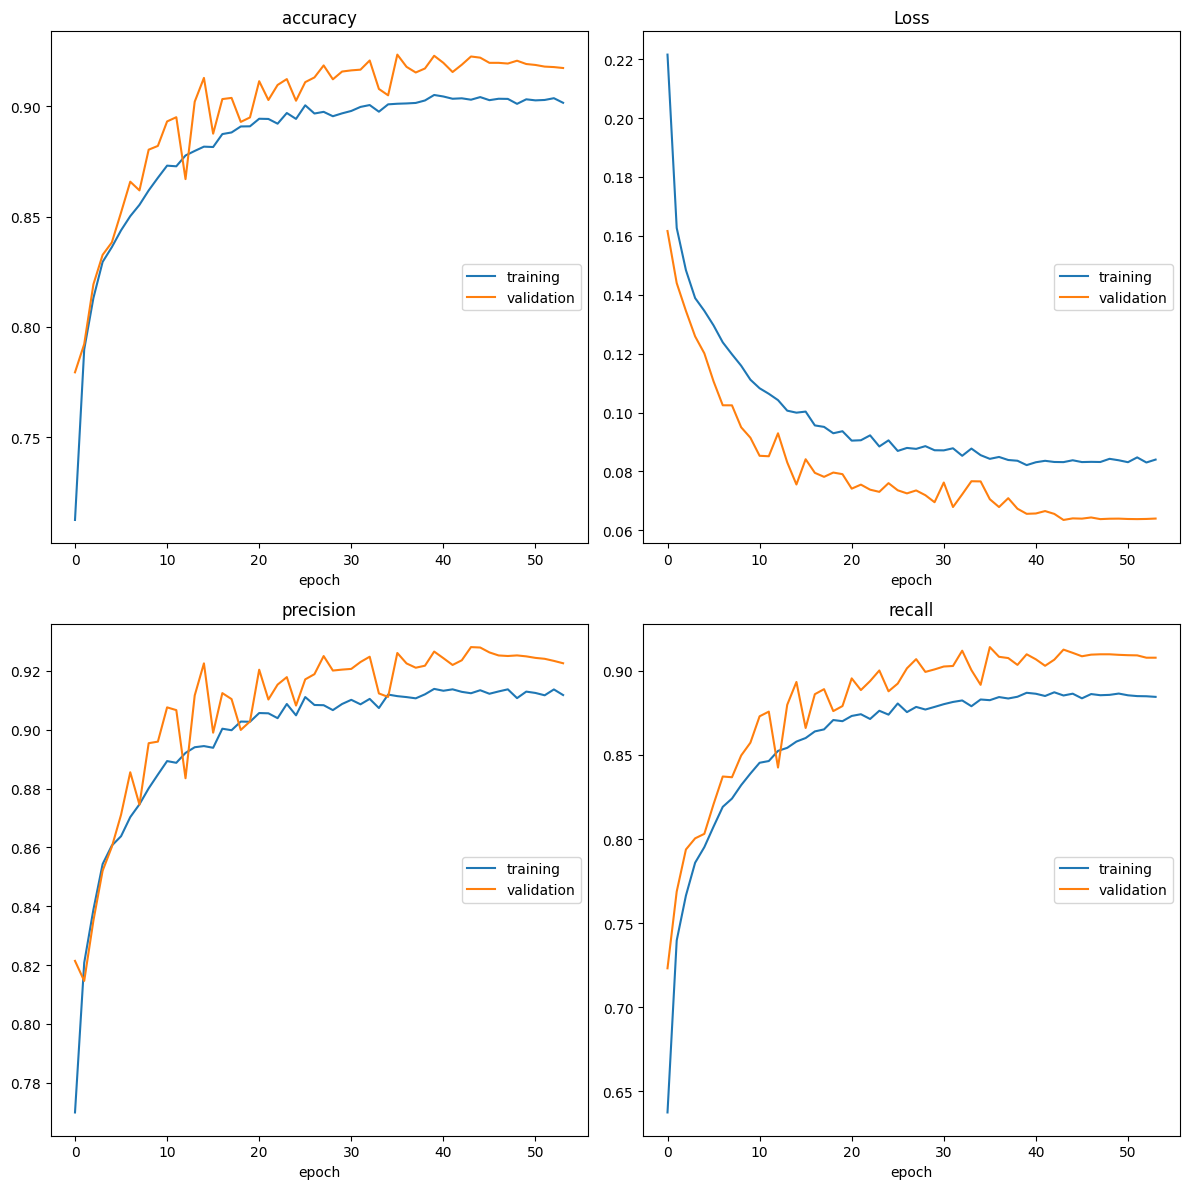

accuracy
	training         	 (min:    0.712, max:    0.905, cur:    0.902)
	validation       	 (min:    0.779, max:    0.924, cur:    0.917)
Loss
	training         	 (min:    0.082, max:    0.222, cur:    0.084)
	validation       	 (min:    0.064, max:    0.162, cur:    0.064)
precision
	training         	 (min:    0.770, max:    0.914, cur:    0.912)
	validation       	 (min:    0.815, max:    0.928, cur:    0.923)
recall
	training         	 (min:    0.638, max:    0.887, cur:    0.884)
	validation       	 (min:    0.723, max:    0.914, cur:    0.908)
1368/1368 - 73s - 54ms/step - accuracy: 0.9017 - loss: 0.0840 - precision: 0.9118 - recall: 0.8845 - val_accuracy: 0.9174 - val_loss: 0.0640 - val_precision: 0.9226 - val_recall: 0.9077 - learning_rate: 1.0000e-05
Stopped after 54 epochs


In [7]:
from livelossplot import PlotLossesKeras

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2,
    callbacks=[
        PlotLossesKeras(),  # live train/val loss + accuracy chart in the cell
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=LR_FACTOR,
            patience=LR_PATIENCE,
            min_lr=LR_MIN,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
        ),
    ],
)
print(f"Stopped after {len(history.history['loss'])} epochs")

## Training curves

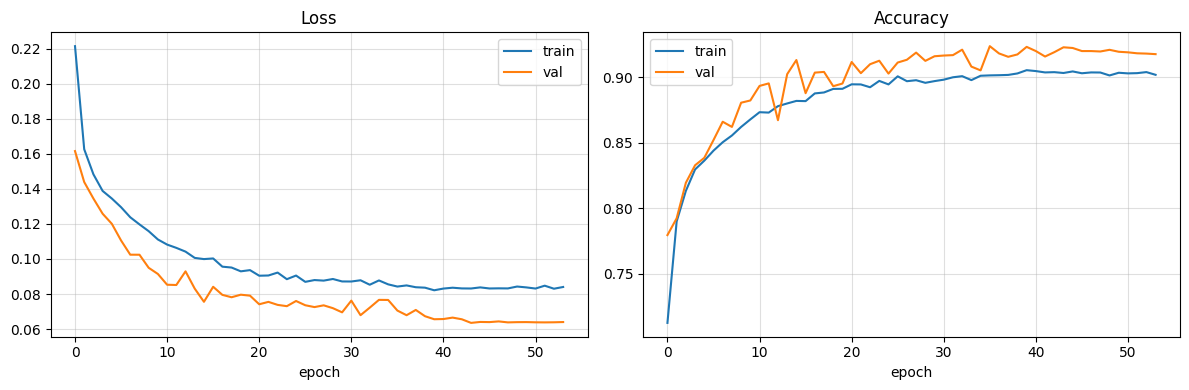

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.4)

acc_key = next(
    (k for k in ("accuracy", "categorical_accuracy") if k in history.history),
    None,
)
if acc_key is not None:
    axes[1].plot(history.history[acc_key], label="train")
    axes[1].plot(history.history[f"val_{acc_key}"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Save float model

Persists the float `.keras` model. PTQ + evaluation happen in `results.ipynb`
so you can re-quantize with different knobs without retraining.

In [9]:
import json

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
model.save(MODEL_PATH)

# Sidecar consumed by results.ipynb so values aren't redeclared there.
MODEL_PATH.with_suffix(".train.json").write_text(json.dumps({
    "collection": COLLECTION,
    "build_model": BUILD_MODEL,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "epochs_trained": len(history.history["loss"]),
}, indent=2))

print(f"Saved float : {MODEL_PATH}")
print("\nRun PTQ and render results via building/geographic_task/results.ipynb.")

Saved float : /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/mel_cnn.keras

Run PTQ and render results via building/geographic_task/results.ipynb.
